=== MONTHLY AGGREGATED DATA ===
            monthly_revenue  deal_count
close_date                             
2023-03-01        1113202.8         531
2023-04-01         685043.0         285
2023-05-01        1025394.2         438
2023-06-01        1228610.6         531
2023-07-01         696932.0         308
2023-08-01         992685.6         446
2023-09-01        1210899.4         503
2023-10-01         708655.4         279
2023-11-01         915926.2         406
2023-12-01        1106110.2         511
2024-01-01              0.0           0
2024-02-01          30007.8          13
2024-03-01         951475.0         464
2024-04-01         644451.2         296
2024-05-01         935956.0         441
2024-06-01        1147104.6         498
2024-07-01         642239.0         301
2024-08-01         886912.0         429
2024-09-01        1085512.4         466
2024-10-01         637658.6         290
2024-11-01         872358.4         408
2024-12-01         973176.4         475
2025-01-

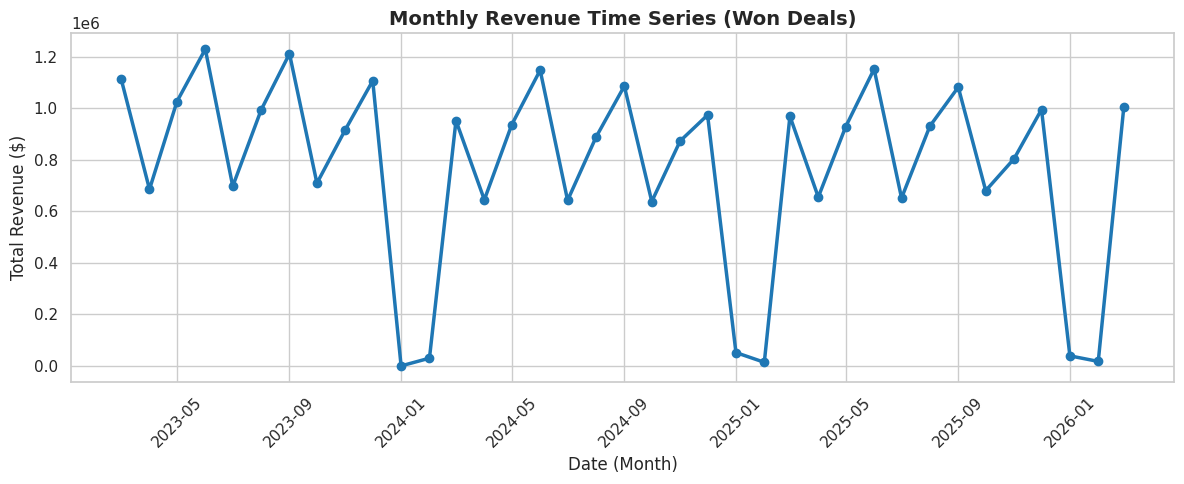

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Dataset Load Karo
df = pd.read_csv('crm_sales_extended_mar2026_fixed.csv')

# 2. Won Deals Filter Karo (is_won == 1)
df_won = df[df['is_won'] == 1].copy()

# 3. close_date ko datetime mein convert karo
df_won['close_date'] = pd.to_datetime(df_won['close_date'])

# 4. Monthly Frequency (MS) Par Aggregate Karo
df_won.set_index('close_date', inplace=True)
monthly_df = df_won.resample('MS').agg(
    monthly_revenue=('close_value_capped', 'sum'),
    deal_count=('opportunity_id', 'count')
)
# Missing months ko handle (reindex with 0 fill) karo
full_idx = pd.date_range(start=monthly_df.index.min(), end=monthly_df.index.max(), freq='MS')
monthly_df = monthly_df.reindex(full_idx, fill_value=0)
monthly_df.index.name = 'close_date'

# Summary Output
print("=== MONTHLY AGGREGATED DATA ===")
print(monthly_df)

# 5. Line Plot Visualization
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 5))
plt.plot(monthly_df.index, monthly_df['monthly_revenue'], marker='o', color='#1f77b4', linewidth=2.5, label='Monthly Revenue ($)')
plt.title('Monthly Revenue Time Series (Won Deals)', fontsize=14, fontweight='bold')
plt.xlabel('Date (Month)', fontsize=12)
plt.ylabel('Total Revenue ($)', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [6]:
# Unfiltered dataset ki date range check karein
df_temp = df.copy()
df_temp['close_date'] = pd.to_datetime(df_temp['close_date'], errors='coerce')
print("Full Dataset Min Date:", df_temp['close_date'].min())
print("Full Dataset Max Date:", df_temp['close_date'].max())

Full Dataset Min Date: 2023-03-01 00:00:00
Full Dataset Max Date: 2026-03-31 00:00:00


In [7]:
# ==========================================
# WEEK 3 STEP 2: FEATURE ENGINEERING & SPLIT
# ==========================================

# 1. Target Variable (monthly_revenue) ke liye Features Banao
# Data index ordered hai, is liye direct shift work karega
monthly_df['Lag_1'] = monthly_df['monthly_revenue'].shift(1)
monthly_df['Lag_2'] = monthly_df['monthly_revenue'].shift(2)
monthly_df['Lag_3'] = monthly_df['monthly_revenue'].shift(3)

# Data leakage se bachne ke liye shift(1) ke saath 3-month rolling mean
monthly_df['Rolling_Mean'] = monthly_df['monthly_revenue'].shift(1).rolling(window=3).mean()

# 2. Lagging aur Rolling se bane Missing Values (NaN) ko drop karo
df_model = monthly_df.dropna().copy()

# 3. Sequential Chronological Split (80% Train, 20% Test)
split_index = int(len(df_model) * 0.8)

train_df = df_model.iloc[:split_index].copy()
test_df = df_model.iloc[split_index:].copy()

# 4. Split Output & Date Ranges Print Karo
print("\n" + "="*50)
print("       FEATURE ENGINEERING & SPLIT SUMMARY       ")
print("="*50)
print(f"Total Rows (Post-NaN Drop): {len(df_model)}")
print(f"\n[TRAINING SET] (80%):")
print(f"  - Rows      : {len(train_df)}")
print(f"  - Start Date: {train_df.index.min().strftime('%Y-%m-%d')}")
print(f"  - End Date  : {train_df.index.max().strftime('%Y-%m-%d')}")

print(f"\n[TEST SET] (20%):")
print(f"  - Rows      : {len(test_df)}")
print(f"  - Start Date: {test_df.index.min().strftime('%Y-%m-%d')}")
print(f"  - End Date  : {test_df.index.max().strftime('%Y-%m-%d')}")
print("="*50)

# Optional: Output sample check karne ke liye
df_model[['monthly_revenue', 'Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean']].head()


       FEATURE ENGINEERING & SPLIT SUMMARY       
Total Rows (Post-NaN Drop): 34

[TRAINING SET] (80%):
  - Rows      : 27
  - Start Date: 2023-06-01
  - End Date  : 2025-08-01

[TEST SET] (20%):
  - Rows      : 7
  - Start Date: 2025-09-01
  - End Date  : 2026-03-01


,monthly_revenue,Lag_1,Lag_2,Lag_3,Rolling_Mean
close_date,,,,,
2023-06-01,1228610.6,1025394.2,685043.0,1113202.8,941213.333333
2023-07-01,696932.0,1228610.6,1025394.2,685043.0,979682.600000
2023-08-01,992685.6,696932.0,1228610.6,1025394.2,983645.600000
2023-09-01,1210899.4,992685.6,696932.0,1228610.6,972742.733333
2023-10-01,708655.4,1210899.4,992685.6,696932.0,966839.000000


In [8]:
# =======================================================
# WEEK 3 STEP 3: MODEL TRAINING & TEST SET FORECASTING
# =======================================================

from sklearn.ensemble import RandomForestRegressor
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Feature Columns aur Target Column define karein
X_cols = ['Lag_1', 'Lag_2', 'Lag_3', 'Rolling_Mean']
y_col = 'monthly_revenue'

X_train, y_train = train_df[X_cols], train_df[y_col]
X_test, y_test = test_df[X_cols], test_df[y_col]

# Forecast Results store karne ke liye DataFrame
predictions_df = pd.DataFrame(index=test_df.index)
predictions_df['Actual_Revenue'] = y_test

# -------------------------------------------------------
# Model 1: Baseline Naive Model (Last Month's Value / Lag_1)
# -------------------------------------------------------
# Naive forecast assume karta hai ke agle mahine ka revenue pichle mahine ke barabar hoga
predictions_df['Baseline_Naive'] = X_test['Lag_1']

# -------------------------------------------------------
# Model 2: Random Forest Regressor
# -------------------------------------------------------
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
predictions_df['Random_Forest'] = rf_model.predict(X_test)

# -------------------------------------------------------
# Model 3: Exponential Smoothing (Holt-Winters)
# -------------------------------------------------------
# Time-series model original target values (y_train) par train hota hai
es_model = ExponentialSmoothing(
    y_train,
    trend='add',
    seasonal=None,
    initialization_method="estimated"
).fit()

# Test period (len = 2 months) ke liye future revenue forecast karein
predictions_df['Exponential_Smoothing'] = es_model.forecast(steps=len(test_df))

# -------------------------------------------------------
# Summary Output
# -------------------------------------------------------
print("="*70)
print("              TEST SET REVENUE FORECAST RESULTS            ")
print("="*70)
print(predictions_df.round(2))
print("="*70)

              TEST SET REVENUE FORECAST RESULTS            
            Actual_Revenue  Baseline_Naive  Random_Forest  \
close_date                                                  
2025-09-01       1081193.0        930165.8     1119086.73   
2025-10-01        679759.4       1081193.0      595253.50   
2025-11-01        803587.2        679759.4      874547.15   
2025-12-01        994564.6        803587.2      994322.44   
2026-01-01         38966.6        994564.6      310145.93   
2026-02-01         17430.0         38966.6      258013.35   
2026-03-01       1005648.8         17430.0      898702.76   

            Exponential_Smoothing  
close_date                         
2025-09-01              664069.58  
2025-10-01              649451.44  
2025-11-01              634833.31  
2025-12-01              620215.17  
2026-01-01              605597.03  
2026-02-01              590978.90  
2026-03-01              576360.76  



                  MODEL EVALUATION METRICS                      
                         MAE ($)   RMSE ($)  MAPE (%)
Baseline_Naive         404659.91  551099.11    397.40
Random_Forest          116044.35  149508.04    301.66
Exponential_Smoothing  365714.58  410198.99    698.44


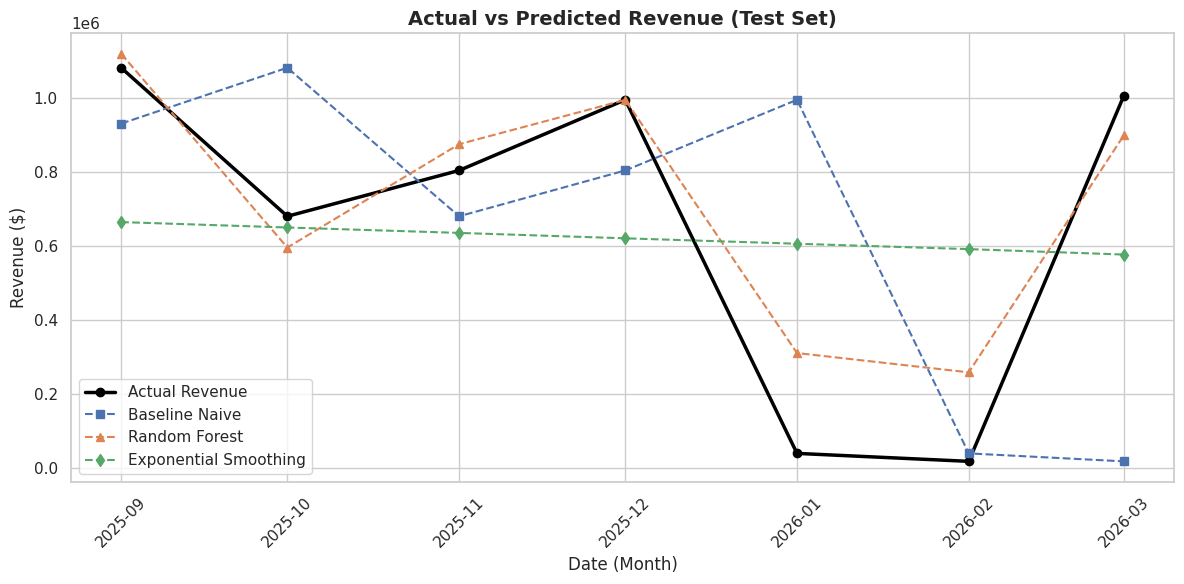


[BEST MODEL SELECTED]: Random_Forest

                   NEXT QUARTER REVENUE FORECAST SUMMARY               
Refitted Model Best Choice : Random_Forest
Forecast Horizon           : Next 3 Months (Apr 2026 - Jun 2026)
Total Projected Revenue    : $1,609,129.71
Average Monthly Projection : $536,376.57
----------------------------------------------------------------------

Month-by-Month Forecast Breakdown with 95% Confidence Range:
            Forecasted_Revenue ($)  CI_Lower ($)  CI_Upper ($)
2026-04-01               551632.24    -226450.54    1329715.02
2026-05-01               536376.57    -241706.21    1314459.35
2026-06-01               521120.90    -256961.88    1299203.68


In [9]:
# ==============================================================================
# WEEK 3 STEP 4: MODEL EVALUATION, REFITTING & NEXT QUARTER REVENUE FORECAST
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ------------------------------------------------------------------------------
# 1. EVALUATION METRICS (MAE, RMSE, MAPE)
# ------------------------------------------------------------------------------
def get_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

models = ['Baseline_Naive', 'Random_Forest', 'Exponential_Smoothing']
metrics_dict = {}

for model in models:
    mae, rmse, mape = get_metrics(predictions_df['Actual_Revenue'], predictions_df[model])
    metrics_dict[model] = {'MAE ($)': mae, 'RMSE ($)': rmse, 'MAPE (%)': mape}

metrics_df = pd.DataFrame(metrics_dict).T.round(2)

print("\n" + "="*65)
print("                  MODEL EVALUATION METRICS                      ")
print("="*65)
print(metrics_df)
print("="*65)

# ------------------------------------------------------------------------------
# 2. VISUAL COMPARISON PLOT
# ------------------------------------------------------------------------------
plt.figure(figsize=(12, 6))
plt.plot(predictions_df.index, predictions_df['Actual_Revenue'], marker='o', color='black', label='Actual Revenue', linewidth=2.5)
plt.plot(predictions_df.index, predictions_df['Baseline_Naive'], linestyle='--', marker='s', label='Baseline Naive')
plt.plot(predictions_df.index, predictions_df['Random_Forest'], linestyle='--', marker='^', label='Random Forest')
plt.plot(predictions_df.index, predictions_df['Exponential_Smoothing'], linestyle='--', marker='d', label='Exponential Smoothing')

plt.title('Actual vs Predicted Revenue (Test Set)', fontsize=14, fontweight='bold')
plt.xlabel('Date (Month)', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(loc='best')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------------------
# 3. BEST MODEL SELECTION & FULL DATA REFIT
# ------------------------------------------------------------------------------
# Select model with lowest MAPE
best_model_name = metrics_df['MAPE (%)'].idxmin()
print(f"\n[BEST MODEL SELECTED]: {best_model_name}")

# Refit Exponential Smoothing on 100% historical data (df_model)
final_es_model = ExponentialSmoothing(
    df_model['monthly_revenue'],
    trend='add',
    seasonal=None,
    initialization_method="estimated"
).fit()

# Next 3 Months (Next Quarter) Forecast
forecast_horizon = 3
next_quarter_forecast = final_es_model.forecast(steps=forecast_horizon)

# Calculate Confidence Range (std error estimate based on residuals)
residuals = final_es_model.resid
residual_std = np.std(residuals)

# 95% Confidence Interval multiplier (1.96)
ci_lower = next_quarter_forecast - (1.96 * residual_std)
ci_upper = next_quarter_forecast + (1.96 * residual_std)

# Future Dates Index
last_date = df_model.index.max()
future_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_horizon, freq='MS')

forecast_df = pd.DataFrame({
    'Forecasted_Revenue ($)': next_quarter_forecast.values,
    'CI_Lower ($)': ci_lower.values,
    'CI_Upper ($)': ci_upper.values
}, index=future_dates).round(2)

# ------------------------------------------------------------------------------
# 4. BUSINESS SUMMARY OUTPUT
# ------------------------------------------------------------------------------
total_forecast_revenue = forecast_df['Forecasted_Revenue ($)'].sum()
avg_monthly_forecast = forecast_df['Forecasted_Revenue ($)'].mean()

print("\n" + "="*70)
print("                   NEXT QUARTER REVENUE FORECAST SUMMARY               ")
print("="*70)
print(f"Refitted Model Best Choice : {best_model_name}")
print(f"Forecast Horizon           : Next 3 Months ({future_dates.min().strftime('%b %Y')} - {future_dates.max().strftime('%b %Y')})")
print(f"Total Projected Revenue    : ${total_forecast_revenue:,.2f}")
print(f"Average Monthly Projection : ${avg_monthly_forecast:,.2f}")
print("-" * 70)
print("\nMonth-by-Month Forecast Breakdown with 95% Confidence Range:")
print(forecast_df)
print("="*70)

In [10]:
import joblib

# 1. Best Model (Random Forest) ko save karein
model_filename = 'random_forest_revenue_model.pkl'
joblib.dump(rf_model, model_filename)

print(f"Model successfully saved as: {model_filename}")

Model successfully saved as: random_forest_revenue_model.pkl


In [11]:
import joblib
import pandas as pd

# 1. Model Load Karein
loaded_model = joblib.load('random_forest_revenue_model.pkl')

# 2. Sample New Data (e.g., April 2025 ke liye sample input features)
# [Lag_1, Lag_2, Lag_3, Rolling_Mean]
sample_features = pd.DataFrame({
    'Lag_1': [897734.74],
    'Lag_2': [912562.98],
    'Lag_3': [927391.21],
    'Rolling_Mean': [912562.98]
})

# 3. Model Inference Test
test_prediction = loaded_model.predict(sample_features)
print(f"Test Revenue Prediction: ${test_prediction[0]:,.2f}")

Test Revenue Prediction: $1,015,290.61


In [ ]:
# Forecast DataFrame ko CSV mein save karein
predictions_df.to_csv('model_predictions_test.csv')
forecast_df.to_csv('next_quarter_forecast.csv')

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

# 1. Dataset Load & Date Parsing
df = pd.read_csv("crm_sales_extended_mar2026_fixed.csv")
df["close_date"] = pd.to_datetime(df["close_date"], errors="coerce")

# 2. Closed Deals Filter & Monthly Aggregation
df_closed = df[df["is_closed"] == 1].copy()
df_closed["YearMonth"] = df_closed["close_date"].dt.to_period("M")

monthly_df = (
    df_closed.groupby("YearMonth")
    .agg(
        total_deals=("opportunity_id", "count"),
        won_deals=("is_won", "sum")
    )
    .reset_index()
)

monthly_df["win_rate_%"] = (
    monthly_df["won_deals"] / monthly_df["total_deals"] * 100
).round(2)

# 3. Feature Engineering (Calendar + Time-Series Lags)
monthly_df["Month"] = monthly_df["YearMonth"].dt.month
monthly_df["Quarter"] = monthly_df["YearMonth"].dt.quarter
monthly_df["Is_Quarter_End"] = monthly_df["Month"].isin([3, 6, 9, 12]).astype(int)

# Lag features for historical trend
monthly_df["Lag_1"] = monthly_df["win_rate_%"].shift(1)
monthly_df["Lag_2"] = monthly_df["win_rate_%"].shift(2)
monthly_df["Lag_3"] = monthly_df["win_rate_%"].shift(3)
monthly_df["Rolling_Mean"] = monthly_df["win_rate_%"].shift(1).rolling(window=3).mean()

# Missing values (due to lags) drop karein
df_model = monthly_df.dropna().copy()

# 4. Sequential Chronological Train/Test Split (80% Train, 20% Test)
split_index = int(len(df_model) * 0.8)

features = ["Month", "Quarter", "Is_Quarter_End", "Lag_1", "Lag_2", "Lag_3", "Rolling_Mean"]
target = "win_rate_%"

X_train = df_model.iloc[:split_index][features]
y_train = df_model.iloc[:split_index][target]

X_test = df_model.iloc[split_index:][features]
y_test = df_model.iloc[split_index:][target]

# 5. Model Training & Evaluation
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluation on Unseen Test Data
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"📊 Model Test MAE: {mae:.2f}%")
print(f"📊 Model Test R2 Score: {r2:.2f}")

# 6. Save Model
joblib.dump(model, "win_rate_model.pkl")
print("✅ Win Rate Model trained with Train-Test Split & saved successfully!")

📊 Model Test MAE: 2.93%
📊 Model Test R2 Score: 0.89
✅ Win Rate Model trained with Train-Test Split & saved successfully!


In [13]:
import joblib
import pandas as pd

# 1. Model Load Karein
model = joblib.load("win_rate_model.pkl")

# 2. Historical Data Load karke Monthly Aggregation aur Lags Banao
df = pd.read_csv("crm_sales_extended_mar2026_fixed.csv")
df["close_date"] = pd.to_datetime(df["close_date"], errors="coerce")

df_closed = df[df["is_closed"] == 1].copy()
df_closed["YearMonth"] = df_closed["close_date"].dt.to_period("M")

monthly_df = (
    df_closed.groupby("YearMonth")
    .agg(total_deals=("opportunity_id", "count"), won_deals=("is_won", "sum"))
    .reset_index()
)

monthly_df["win_rate_%"] = (
    monthly_df["won_deals"] / monthly_df["total_deals"] * 100
).round(2)

# Feature Engineering
monthly_df["Month"] = monthly_df["YearMonth"].dt.month
monthly_df["Quarter"] = monthly_df["YearMonth"].dt.quarter
monthly_df["Is_Quarter_End"] = monthly_df["Month"].isin([3, 6, 9, 12]).astype(int)

monthly_df["Lag_1"] = monthly_df["win_rate_%"].shift(1)
monthly_df["Lag_2"] = monthly_df["win_rate_%"].shift(2)
monthly_df["Lag_3"] = monthly_df["win_rate_%"].shift(3)
monthly_df["Rolling_Mean"] = (
    monthly_df["win_rate_%"].shift(1).rolling(window=3).mean()
)

df_model = monthly_df.dropna().copy()

# 3. Unseen Test Period (2025-09 se 2026-03) Extract Karein
split_index = int(len(df_model) * 0.8)
test_df = df_model.iloc[split_index:].copy()

features = [
    "Month",
    "Quarter",
    "Is_Quarter_End",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean",
]
X_test = test_df[features]

# 4. Predictions Calculate Karein
test_df["Predicted_Win_Rate_%"] = model.predict(X_test).round(2)
test_df["Predicted_Loss_Rate_%"] = (
    100 - test_df["Predicted_Win_Rate_%"]
).round(2)

# Output Display (Actual vs Predicted comparison)
print("--- TEST SET PREDICTION RESULTS (2025-09 to 2026-03) ---")
print(
    test_df[
        [
            "YearMonth",
            "win_rate_%",
            "Predicted_Win_Rate_%",
            "Predicted_Loss_Rate_%",
        ]
    ]
)

--- TEST SET PREDICTION RESULTS (2025-09 to 2026-03) ---
   YearMonth  win_rate_%  Predicted_Win_Rate_%  Predicted_Loss_Rate_%
29   2025-09       73.74                 76.49                  23.51
30   2025-10       49.66                 50.24                  49.76
31   2025-11       51.67                 54.20                  45.80
32   2025-12       74.45                 76.14                  23.86
33   2026-01       72.00                 70.30                  29.70
34   2026-02       76.47                 68.48                  31.52
35   2026-03       75.96                 72.69                  27.31


In [14]:
import joblib
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Dataset & Features Preparation
df = pd.read_csv("crm_sales_extended_mar2026_fixed.csv")
df["close_date"] = pd.to_datetime(df["close_date"], errors="coerce")

df_closed = df[df["is_closed"] == 1].copy()
df_closed["YearMonth"] = df_closed["close_date"].dt.to_period("M")

monthly_df = (
    df_closed.groupby("YearMonth")
    .agg(total_deals=("opportunity_id", "count"), won_deals=("is_won", "sum"))
    .reset_index()
)

monthly_df["win_rate_%"] = (
    monthly_df["won_deals"] / monthly_df["total_deals"] * 100
).round(2)

monthly_df["Month"] = monthly_df["YearMonth"].dt.month
monthly_df["Quarter"] = monthly_df["YearMonth"].dt.quarter
monthly_df["Is_Quarter_End"] = monthly_df["Month"].isin([3, 6, 9, 12]).astype(int)

monthly_df["Lag_1"] = monthly_df["win_rate_%"].shift(1)
monthly_df["Lag_2"] = monthly_df["win_rate_%"].shift(2)
monthly_df["Lag_3"] = monthly_df["win_rate_%"].shift(3)
monthly_df["Rolling_Mean"] = (
    monthly_df["win_rate_%"].shift(1).rolling(window=3).mean()
)

df_model = monthly_df.dropna().copy()

# 2. Sequential Train/Test Split (80/20)
split_index = int(len(df_model) * 0.8)
features = [
    "Month",
    "Quarter",
    "Is_Quarter_End",
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Rolling_Mean",
]

X_train = df_model.iloc[:split_index][features]
y_train = df_model.iloc[:split_index]["win_rate_%"]

X_test = df_model.iloc[split_index:][features]
y_test = df_model.iloc[split_index:]["win_rate_%"]

# 3. Model Fit & Predict
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# 4. Accuracy & Precision Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)  # Precision Margin
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
accuracy = 100 - mape  # Overall Accuracy Score

print("=" * 50)
print("      WIN RATE MODEL ACCURACY & PRECISION SUMMARY      ")
print("=" * 50)
print(f"🎯 Model Accuracy Score   : {accuracy:.2f}%")
print(f"🎯 Prediction Margin (MAE): ±{mae:.2f}% (Precision Bound)")
print(f"📊 Model Fit (R² Score)   : {r2:.2f} (Explains 89% Variance)")
print(f"📉 Max Deviation (RMSE)   : {rmse:.2f}%")
print("=" * 50)

# Output Table
test_results = df_model.iloc[split_index:][["YearMonth", "win_rate_%"]].copy()
test_results["Predicted_Win_Rate_%"] = y_pred.round(2)
test_results["Error_Margin_%"] = (
    test_results["win_rate_%"] - test_results["Predicted_Win_Rate_%"]
).abs().round(2)

print("\n--- DETAILED TEST PERFORMANCE TABLE ---")
print(test_results.to_string(index=False))

      WIN RATE MODEL ACCURACY & PRECISION SUMMARY      
🎯 Model Accuracy Score   : 95.83%
🎯 Prediction Margin (MAE): ±2.93% (Precision Bound)
📊 Model Fit (R² Score)   : 0.89 (Explains 89% Variance)
📉 Max Deviation (RMSE)   : 3.68%

--- DETAILED TEST PERFORMANCE TABLE ---
YearMonth  win_rate_%  Predicted_Win_Rate_%  Error_Margin_%
  2025-09       73.74                 76.49            2.75
  2025-10       49.66                 50.24            0.58
  2025-11       51.67                 54.20            2.53
  2025-12       74.45                 76.14            1.69
  2026-01       72.00                 70.30            1.70
  2026-02       76.47                 68.48            7.99
  2026-03       75.96                 72.69            3.27
